## Data Generation <a id='1-setup'></a>
I simulated 10 years of monthly renewable energy production data (GWh) for Solar, Wind, Hydro, and Geothermal,
incorporating realistic seasonality, trends, and noise.

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
from scipy.signal import savgol_filter

# Aesthetics
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3a3f5c',
    'axes.labelcolor':  '#c8cde4',
    'axes.titlecolor':  '#e8ecff',
    'xtick.color':      '#8891b4',
    'ytick.color':      '#8891b4',
    'text.color':       '#c8cde4',
    'grid.color':       '#2a2f45',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

COLORS = {
    'Solar':      '#FFD166',
    'Wind':       '#06D6A0',
    'Hydro':      '#118AB2',
    'Geothermal': '#EF476F',
    'Total':      '#A78BFA',
}

np.random.seed(42)

In [2]:
# Data Generation
date_range = pd.date_range(start='2014-01-01', end='2023-12-01', freq='MS')
n = len(date_range)
t = np.arange(n)

def make_series(base, trend_rate, seasonal_amp, seasonal_phase, noise_std, floor=5):
    trend    = base + trend_rate * t
    seasonal = seasonal_amp * np.sin(2 * np.pi * t / 12 + seasonal_phase)
    noise    = np.random.normal(0, noise_std, n)
    return np.clip(trend + seasonal + noise, floor, None)

solar       = make_series(base=120,  trend_rate=2.1,  seasonal_amp=70,  seasonal_phase=-np.pi/2, noise_std=12)
wind        = make_series(base=200,  trend_rate=3.5,  seasonal_amp=55,  seasonal_phase=np.pi,    noise_std=20)
hydro       = make_series(base=350,  trend_rate=0.4,  seasonal_amp=80,  seasonal_phase=np.pi/4,  noise_std=15)
geothermal  = make_series(base=80,   trend_rate=0.8,  seasonal_amp=8,   seasonal_phase=0,        noise_std=4)

df = pd.DataFrame({
    'Date':       date_range,
    'Solar':      solar,
    'Wind':       wind,
    'Hydro':      hydro,
    'Geothermal': geothermal,
})
df['Total'] = df[['Solar','Wind','Hydro','Geothermal']].sum(axis=1)
df.set_index('Date', inplace=True)

print(f'Dataset: {df.shape[0]} monthly observations (Jan 2014 – Dec 2023)')
df.round(1).head(12)

Dataset: 120 monthly observations (Jan 2014 – Dec 2023)


,Solar,Wind,Hydro,Geothermal,Total
Date,,,,,
2014-01-01,56.0,215.8,394.7,82.1,748.5
2014-02-01,59.8,157.8,426.0,90.9,734.5
2014-03-01,97.0,187.4,435.6,88.1,808.1
2014-04-01,144.6,127.5,420.8,92.0,784.8
2014-05-01,160.6,178.1,354.3,92.9,785.9
2014-06-01,188.3,233.8,326.3,86.4,834.8
2014-07-01,221.6,201.2,288.7,85.7,797.1
2014-08-01,204.5,240.7,265.7,81.7,792.6
2014-09-01,166.2,277.6,302.4,79.9,826.1


## Exploratory Data Analysis (EDA) <a id='2-eda'></a>

In [3]:
# Descriptive Statistics
stats = df[['Solar','Wind','Hydro','Geothermal','Total']].describe().T
stats['cv%'] = (stats['std'] / stats['mean'] * 100).round(1)   # coefficient of variation
stats.round(1)

,count,mean,std,min,25%,50%,75%,max,cv%
Solar,120.0,244.0,91.3,56.0,176.6,238.0,315.7,447.5,37.4
Wind,120.0,409.7,133.2,127.5,304.0,418.0,521.1,668.2,32.5
Hydro,120.0,373.9,59.4,263.6,320.7,374.8,425.3,479.0,15.9
Geothermal,120.0,127.8,28.1,76.1,104.8,125.0,152.3,179.9,21.9
Total,120.0,1155.5,239.7,734.5,962.2,1156.8,1374.0,1585.5,20.7


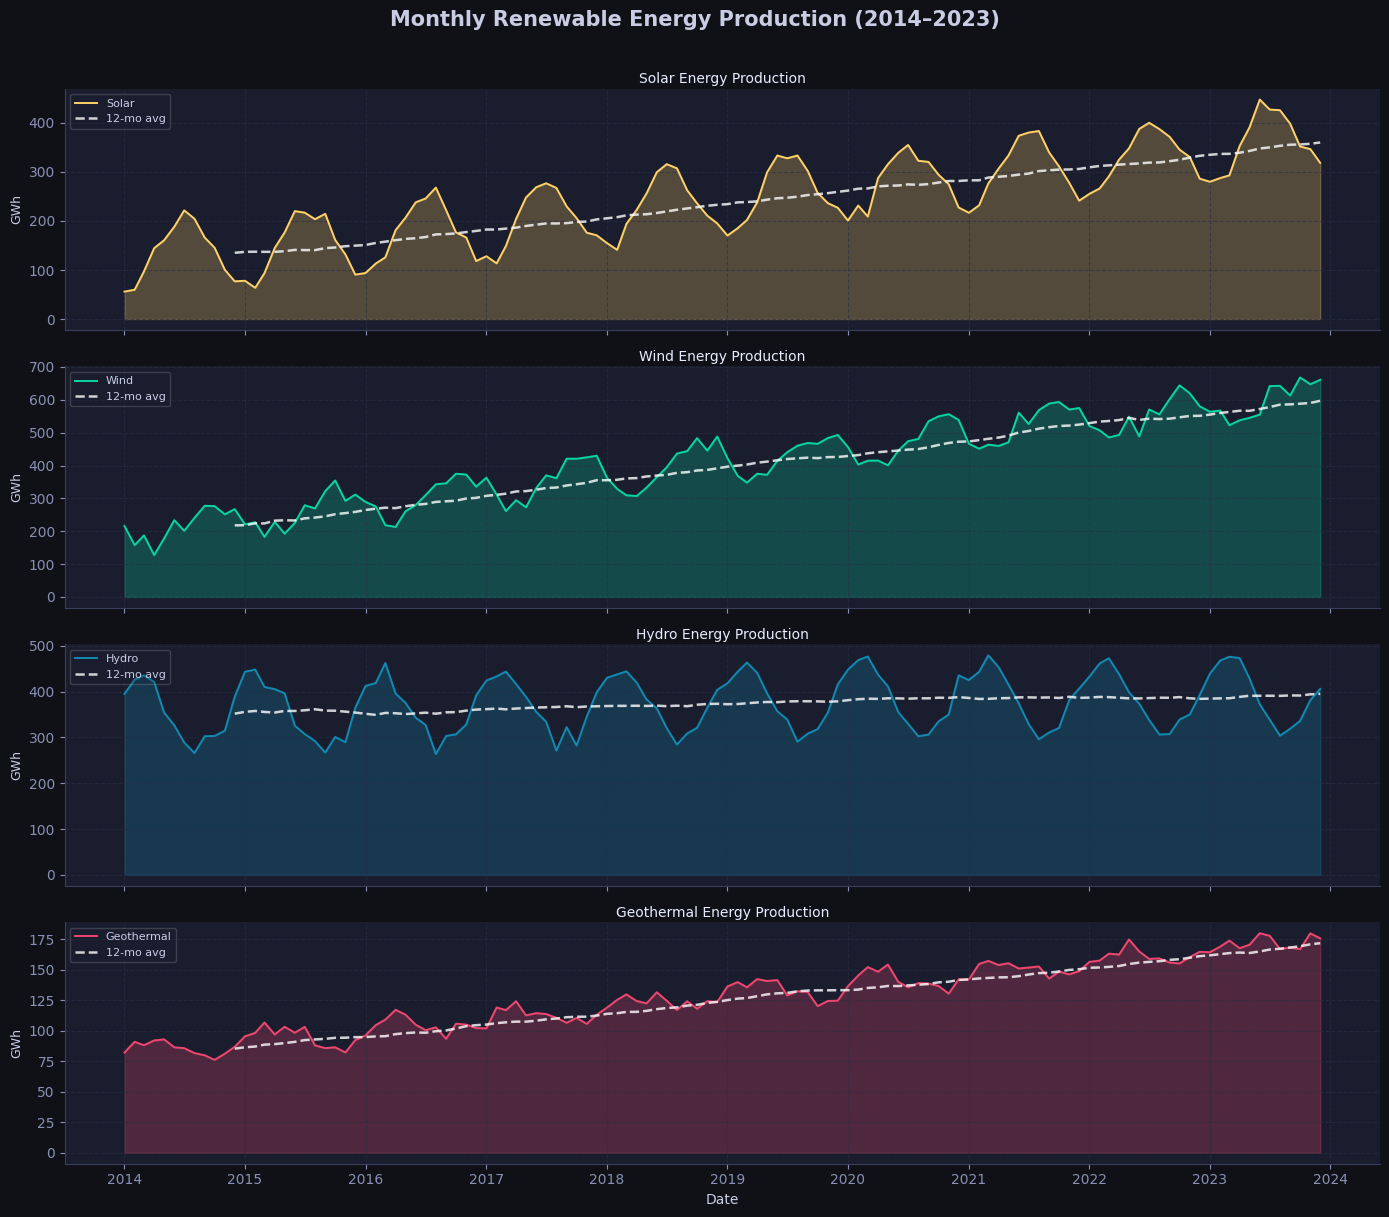

In [4]:
# Time-Series Overview
sources = ['Solar', 'Wind', 'Hydro', 'Geothermal']
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Monthly Renewable Energy Production (2014–2023)', fontsize=15, fontweight='bold', y=1.01)

for ax, src in zip(axes, sources):
    color = COLORS[src]
    ax.fill_between(df.index, df[src], alpha=0.25, color=color)
    ax.plot(df.index, df[src], color=color, linewidth=1.4, label=src)
    # rolling 12-month average
    roll = df[src].rolling(12).mean()
    ax.plot(roll.index, roll, color='white', linewidth=1.8, linestyle='--', alpha=0.8, label='12-mo avg')
    ax.set_ylabel('GWh', fontsize=9)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.2)
    ax.grid(True)
    ax.set_title(f'{src} Energy Production', fontsize=10, pad=4)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

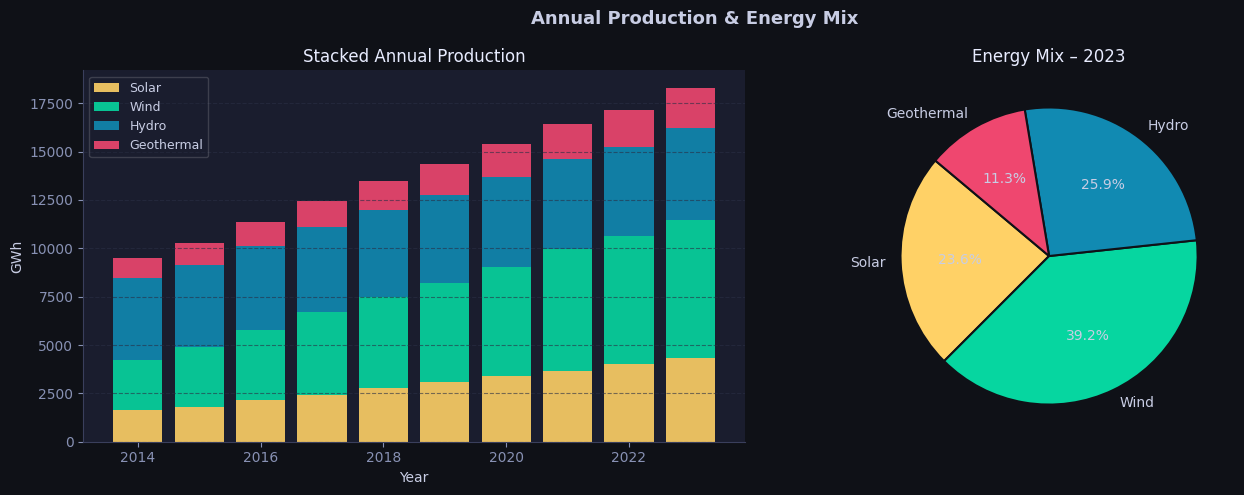


Annual Production (GWh):


,Solar,Wind,Hydro,Geothermal
Date,,,,
2014,1621,2615,4221,1024
2015,1796,3108,4249,1137
2016,2156,3620,4327,1254
2017,2438,4264,4415,1349
2018,2795,4699,4480,1483
2019,3112,5113,4544,1598
2020,3378,5670,4654,1699
2021,3673,6296,4634,1804
2022,3994,6617,4609,1933


In [5]:
# Annual Production & Energy Mix
annual = df.resample('YE')[sources].sum()
annual.index = annual.index.year

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Annual Production & Energy Mix', fontsize=13, fontweight='bold')

# Stacked bar
bottom = np.zeros(len(annual))
for src in sources:
    ax1.bar(annual.index, annual[src], bottom=bottom, color=COLORS[src], label=src, alpha=0.9)
    bottom += annual[src].values
ax1.set_xlabel('Year'); ax1.set_ylabel('GWh')
ax1.set_title('Stacked Annual Production')
ax1.legend(fontsize=9, framealpha=0.2)
ax1.grid(True, axis='y')

# Pie – last year share
last_year = annual.iloc[-1]
wedge_colors = [COLORS[s] for s in sources]
ax2.pie(
    last_year, labels=sources, colors=wedge_colors,
    autopct='%1.1f%%', startangle=140,
    textprops={'color': '#c8cde4', 'fontsize': 10},
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 1.5}
)
ax2.set_title(f'Energy Mix – {annual.index[-1]}')

plt.tight_layout()
plt.show()
print('\nAnnual Production (GWh):')
annual.round(0).astype(int)

## Seasonal & Trend Decomposition <a id='3-decomposition'></a>
I extracted the seasonal profile for each source and visualize long-term growth trends.

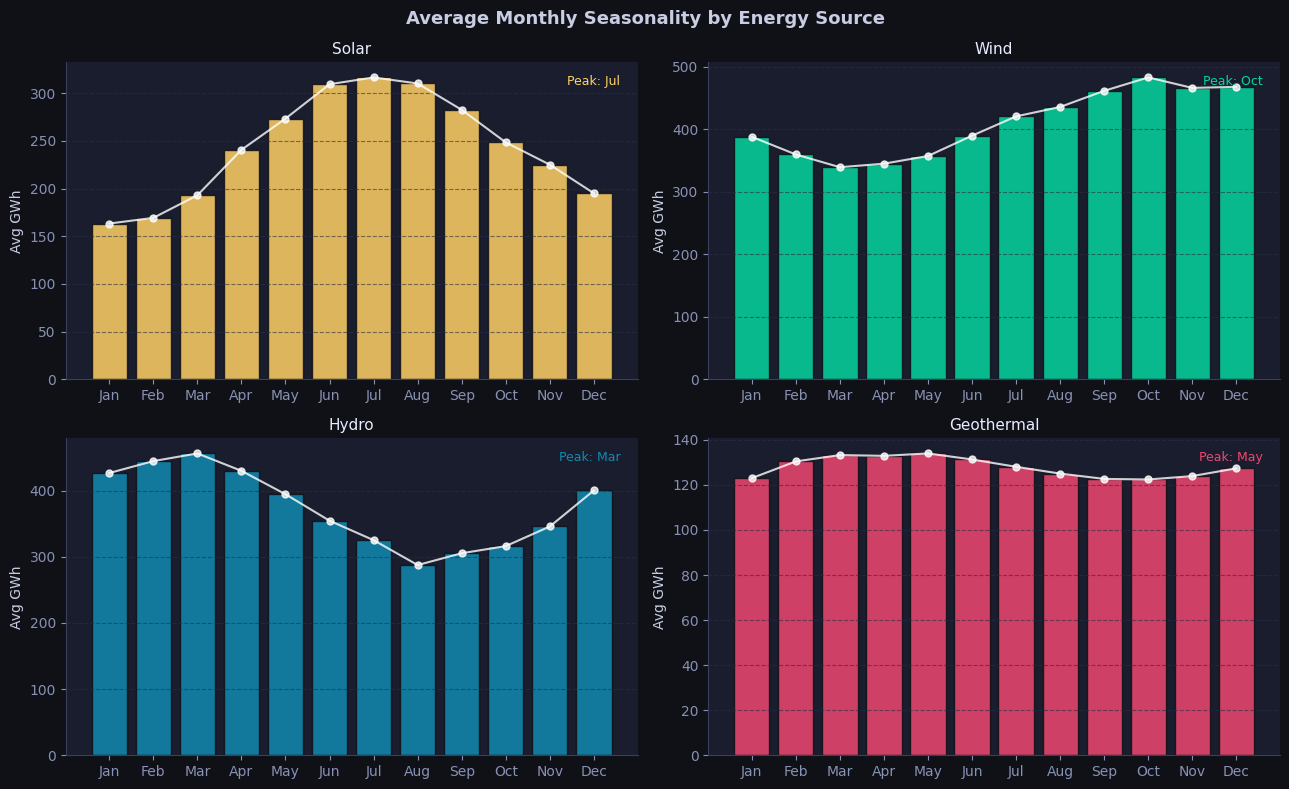

In [6]:
# Monthly Seasonality Profiles
monthly_avg = df[sources].groupby(df.index.month).mean()
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Average Monthly Seasonality by Energy Source', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, src in zip(axes, sources):
    vals = monthly_avg[src]
    bars = ax.bar(monthly_avg.index, vals, color=COLORS[src], alpha=0.85, edgecolor='#0f1117')
    ax.plot(monthly_avg.index, vals, 'o-', color='white', linewidth=1.5, markersize=5, alpha=0.8)
    ax.set_title(f'{src}', fontsize=11)
    ax.set_ylabel('Avg GWh')
    ax.grid(True, axis='y')
    peak_month = monthly_avg[src].idxmax()
    ax.annotate(f'Peak: {peak_month}', xy=(0.97, 0.93), xycoords='axes fraction',
                ha='right', fontsize=9, color=COLORS[src])

plt.tight_layout()
plt.show()

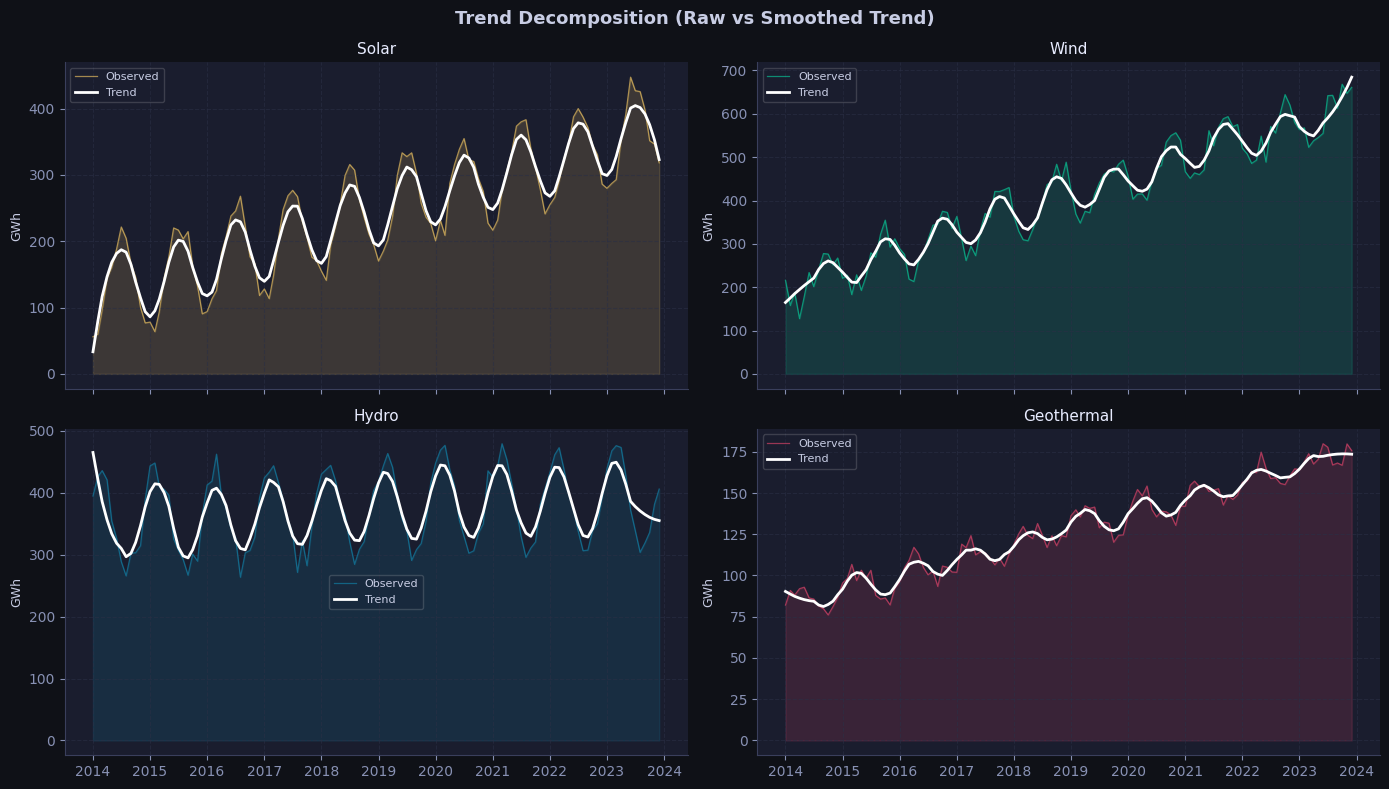

In [7]:
# Trend Decomposition via Savitzky-Golay Filter
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle('Trend Decomposition (Raw vs Smoothed Trend)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, src in zip(axes, sources):
    raw   = df[src].values
    trend = savgol_filter(raw, window_length=13, polyorder=2)
    residual = raw - trend

    ax.fill_between(df.index, raw, alpha=0.15, color=COLORS[src])
    ax.plot(df.index, raw,      color=COLORS[src], linewidth=0.9, alpha=0.6, label='Observed')
    ax.plot(df.index, trend,    color='white',     linewidth=2.0,            label='Trend')
    ax.set_title(src, fontsize=11)
    ax.set_ylabel('GWh', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.2)
    ax.grid(True)

plt.tight_layout()
plt.show()

## Correlation & Efficiency Analysis <a id='4-correlation'></a>

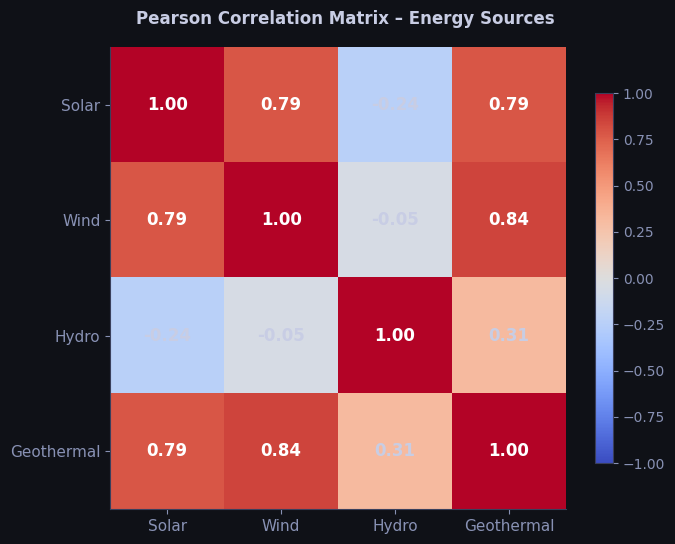

In [8]:
# Correlation Heatmap
corr = df[sources].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.suptitle('Pearson Correlation Matrix – Energy Sources', fontsize=12, fontweight='bold')

cmap = plt.cm.coolwarm
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(sources))); ax.set_xticklabels(sources, fontsize=11)
ax.set_yticks(range(len(sources))); ax.set_yticklabels(sources, fontsize=11)

for i in range(len(sources)):
    for j in range(len(sources)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if abs(corr.iloc[i,j]) > 0.5 else '#c8cde4')

plt.tight_layout()
plt.show()

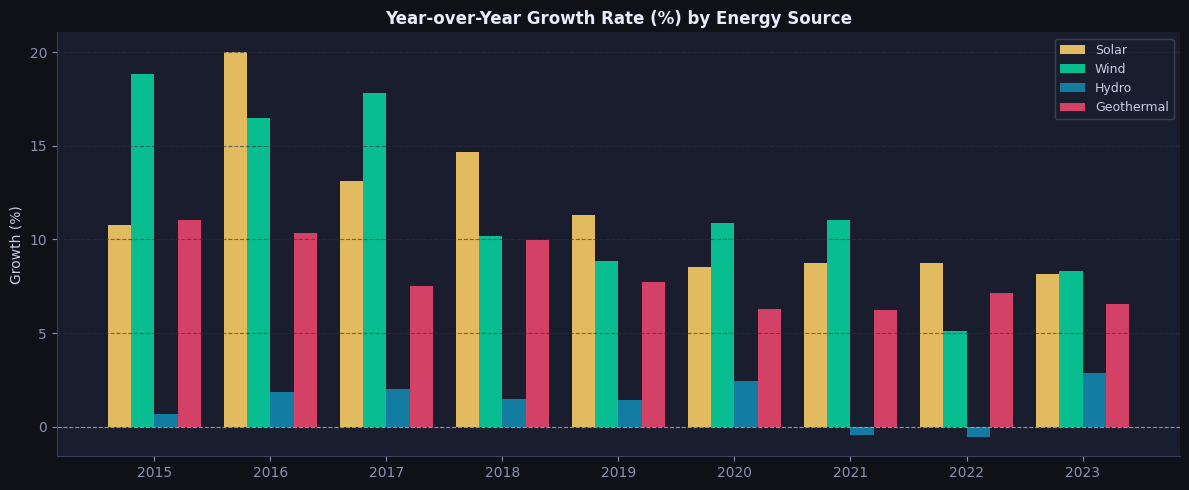


Year-over-Year Growth (%):


,Solar,Wind,Hydro,Geothermal
Date,,,,
2015,10.8,18.8,0.7,11.0
2016,20.0,16.5,1.8,10.4
2017,13.1,17.8,2.0,7.5
2018,14.7,10.2,1.5,10.0
2019,11.3,8.8,1.4,7.7
2020,8.6,10.9,2.4,6.3
2021,8.7,11.0,-0.4,6.2
2022,8.7,5.1,-0.5,7.1
2023,8.1,8.3,2.9,6.6


In [9]:
# Year-over-Year Growth Rates
annual_full = df.resample('YE')[sources].sum()
annual_full.index = annual_full.index.year
yoy = annual_full.pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Year-over-Year Growth Rate (%) by Energy Source', fontsize=12, fontweight='bold')

x = np.arange(len(yoy.index[1:]))
bar_w = 0.2
for i, src in enumerate(sources):
    vals = yoy[src].dropna().values
    ax.bar(x + i*bar_w, vals, width=bar_w, color=COLORS[src], alpha=0.88, label=src)

ax.axhline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x + bar_w * 1.5)
ax.set_xticklabels(yoy.index[1:].astype(str))
ax.set_ylabel('Growth (%)')
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print('\nYear-over-Year Growth (%):')
yoy.round(1).dropna()

## Forecasting with Polynomial Regression <a id='5-forecasting-lr'></a>
I fitted a polynomial trend model on training data (2014–2021) and forecast 2022–2025.

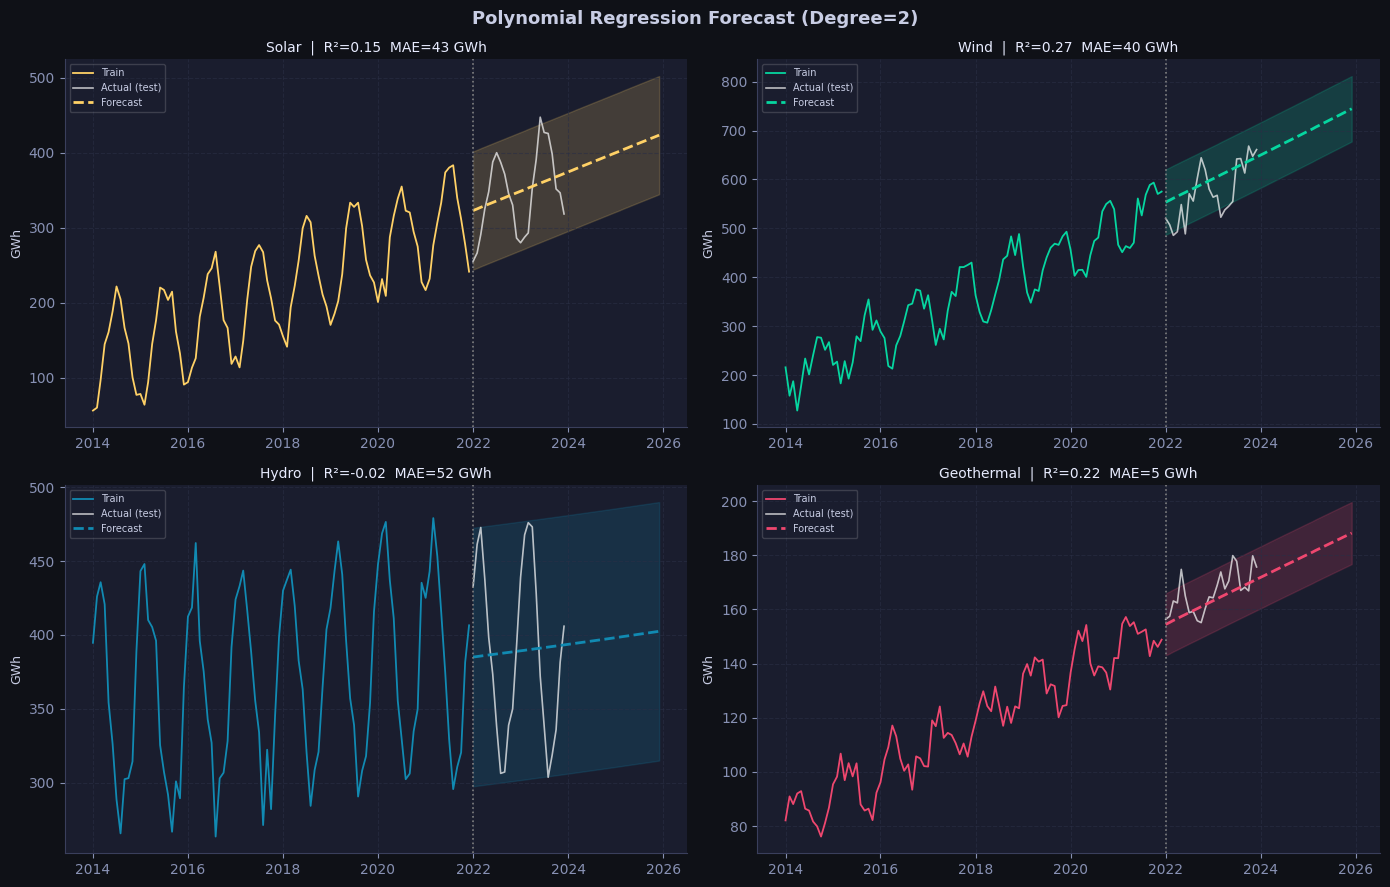

In [10]:
# Polynomial Regression Forecast
TRAIN_END   = '2021-12-01'
TEST_START  = '2022-01-01'
FORE_END    = '2025-12-01'

forecast_dates = pd.date_range(start=TEST_START, end=FORE_END, freq='MS')
all_dates      = pd.date_range(start='2014-01-01', end=FORE_END, freq='MS')
t_all          = np.arange(len(all_dates)).reshape(-1, 1)

train_mask = df.index <= TRAIN_END
test_mask  = df.index >= TEST_START

poly_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
fig.suptitle('Polynomial Regression Forecast (Degree=2)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for ax, src in zip(axes, sources):
    t_train = t_all[:train_mask.sum()]
    y_train = df.loc[train_mask, src].values
    t_test  = t_all[train_mask.sum():train_mask.sum() + test_mask.sum()]
    y_test  = df.loc[test_mask, src].values

    # Fit poly degree-2
    pf = PolynomialFeatures(degree=2, include_bias=True)
    lr = LinearRegression()
    lr.fit(pf.fit_transform(t_train), y_train)

    # Predict over full horizon
    t_fore = np.arange(train_mask.sum(), len(all_dates)).reshape(-1,1)
    preds  = lr.predict(pf.transform(t_fore))
    preds  = np.clip(preds, 0, None)

    # CI: ±1.5 std of training residuals
    train_resid_std = np.std(y_train - lr.predict(pf.transform(t_train)))
    preds_upper = preds + 1.5 * train_resid_std
    preds_lower = np.clip(preds - 1.5 * train_resid_std, 0, None)

    # Metrics on test set overlap
    n_test = min(len(t_test), len(preds))
    mae  = mean_absolute_error(y_test[:n_test], preds[:n_test])
    rmse = np.sqrt(mean_squared_error(y_test[:n_test], preds[:n_test]))
    r2   = r2_score(y_test[:n_test], preds[:n_test])
    poly_results[src] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    fore_dates_plot = all_dates[train_mask.sum():]

    # Plot
    ax.fill_between(fore_dates_plot, preds_lower, preds_upper, alpha=0.18, color=COLORS[src])
    ax.plot(df.index[train_mask], df.loc[train_mask, src], color=COLORS[src], lw=1.3, label='Train')
    ax.plot(df.index[test_mask],  df.loc[test_mask,  src], color='white',     lw=1.2, linestyle='-', alpha=0.7, label='Actual (test)')
    ax.plot(fore_dates_plot,      preds,                   color=COLORS[src], lw=2.0, linestyle='--', label='Forecast')
    ax.axvline(pd.Timestamp(TEST_START), color='grey', linestyle=':', lw=1.2)
    ax.set_title(f'{src}  |  R²={r2:.2f}  MAE={mae:.0f} GWh', fontsize=10)
    ax.set_ylabel('GWh', fontsize=9)
    ax.legend(fontsize=7, framealpha=0.2)
    ax.grid(True)

plt.tight_layout()
plt.show()

## Forecasting with Exponential Smoothing (Holt-Winters) <a id='6-forecasting-sarima'></a>
Manual triple exponential smoothing to capture level, trend, and seasonality.

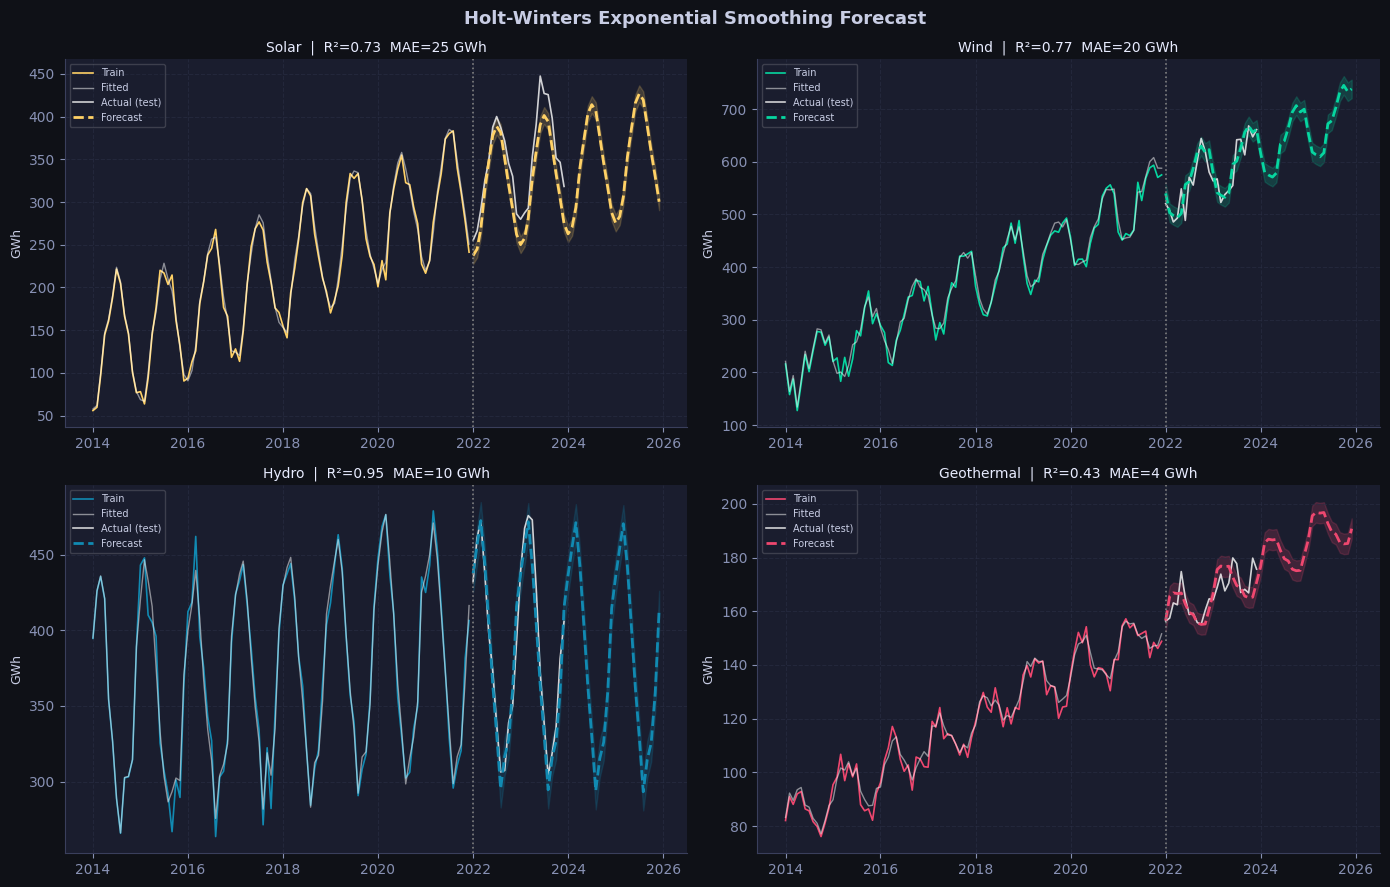

In [11]:
# Holt-Winters Triple Exponential Smoothing (manual)

def holt_winters_forecast(series, season_len=12, alpha=0.3, beta=0.1, gamma=0.2, h=48):
    """Additive Holt-Winters multiplicative seasonality."""
    y = series.values.copy().astype(float)
    n = len(y)

    # Initialise
    level  = np.mean(y[:season_len])
    trend  = (np.mean(y[season_len:2*season_len]) - np.mean(y[:season_len])) / season_len
    season = [y[i] - level for i in range(season_len)]

    fitted = []
    for i in range(n):
        s_idx = i % season_len
        prev_level = level
        prev_trend = trend
        level  = alpha * (y[i] - season[s_idx]) + (1 - alpha) * (level + trend)
        trend  = beta  * (level - prev_level)   + (1 - beta)  * trend
        season[s_idx] = gamma * (y[i] - prev_level - prev_trend) + (1 - gamma) * season[s_idx]
        fitted.append(level + trend + season[s_idx])

    # Forecast
    forecast = []
    for k in range(1, h+1):
        s_idx = (n + k - 1) % season_len
        forecast.append(level + k * trend + season[s_idx])

    return np.array(fitted), np.clip(np.array(forecast), 0, None)


hw_results = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False)
fig.suptitle('Holt-Winters Exponential Smoothing Forecast', fontsize=13, fontweight='bold')
axes = axes.flatten()

forecast_h = len(forecast_dates)

for ax, src in zip(axes, sources):
    train_series = df.loc[train_mask, src]
    test_series  = df.loc[test_mask,  src]

    fitted, forecast_vals = holt_winters_forecast(train_series, h=forecast_h)

    # Metrics on test overlap
    n_test = min(len(test_series), len(forecast_vals))
    mae  = mean_absolute_error(test_series.values[:n_test], forecast_vals[:n_test])
    rmse = np.sqrt(mean_squared_error(test_series.values[:n_test], forecast_vals[:n_test]))
    r2   = r2_score(test_series.values[:n_test], forecast_vals[:n_test])
    hw_results[src] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    resid_std = np.std(train_series.values - fitted)

    ax.plot(df.index[train_mask], train_series, color=COLORS[src], lw=1.2, label='Train')
    ax.plot(df.index[train_mask], fitted,        color='white',     lw=1.0, linestyle='-', alpha=0.5, label='Fitted')
    ax.plot(df.index[test_mask],  test_series,   color='white',     lw=1.2, alpha=0.8,    label='Actual (test)')
    ax.plot(forecast_dates,       forecast_vals, color=COLORS[src], lw=2.0, linestyle='--', label='Forecast')
    ax.fill_between(forecast_dates,
                    np.clip(forecast_vals - 1.5*resid_std, 0, None),
                    forecast_vals + 1.5*resid_std,
                    alpha=0.18, color=COLORS[src])
    ax.axvline(pd.Timestamp(TEST_START), color='grey', linestyle=':', lw=1.2)
    ax.set_title(f'{src}  |  R²={r2:.2f}  MAE={mae:.0f} GWh', fontsize=10)
    ax.set_ylabel('GWh', fontsize=9)
    ax.legend(fontsize=7, framealpha=0.2)
    ax.grid(True)

plt.tight_layout()
plt.show()

## Forecast Comparison & Model Evaluation <a id='7-evaluation'></a>

In [12]:
# Side-by-Side Metrics
rows = []
for src in sources:
    for model, res in [('Poly-Regression', poly_results), ('Holt-Winters', hw_results)]:
        rows.append({'Source': src, 'Model': model,
                     'MAE (GWh)': round(res[src]['MAE'], 1),
                     'RMSE (GWh)': round(res[src]['RMSE'], 1),
                     'R²': round(res[src]['R2'], 3)})

metrics_df = pd.DataFrame(rows).set_index(['Source', 'Model'])
print(' Model Evaluation on Test Set (2022–2023) ')
metrics_df

 Model Evaluation on Test Set (2022–2023) 


MAE (GWh)  RMSE (GWh)     R²
Source     Model                                        
Solar      Poly-Regression       42.9        49.2  0.149
           Holt-Winters          24.6        27.7  0.731
Wind       Poly-Regression       40.1        47.9  0.274
           Holt-Winters          20.1        26.9  0.771
Hydro      Poly-Regression       51.6        58.4 -0.024
           Holt-Winters          10.1        12.4  0.954
Geothermal Poly-Regression        5.0         6.6  0.223
           Holt-Winters           4.4         5.6  0.435

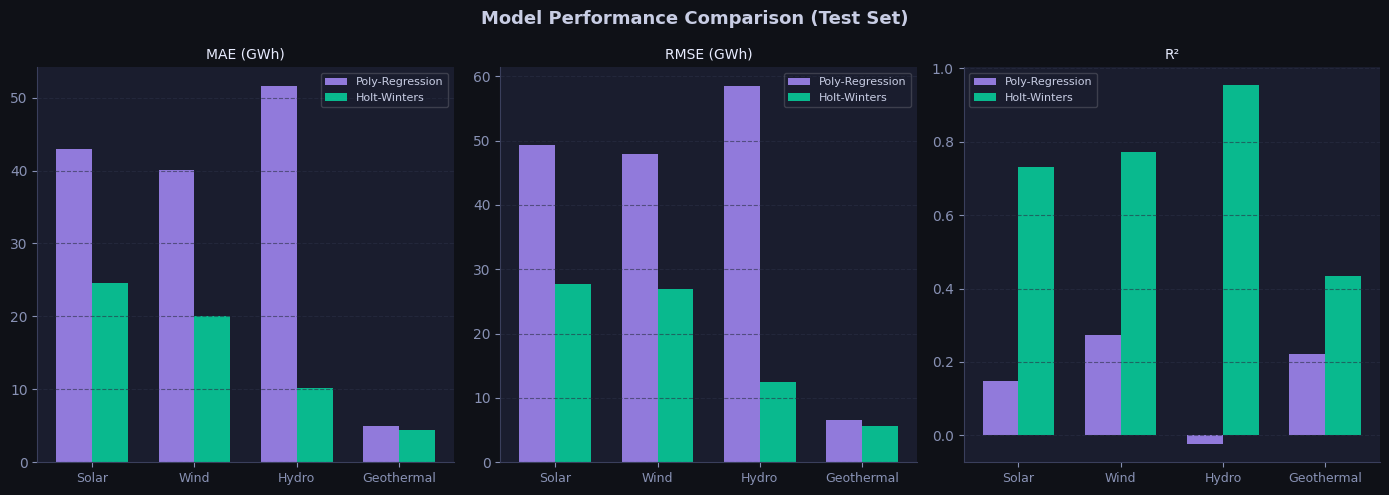

In [13]:
# Radar / Bar comparison of R²
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Performance Comparison (Test Set)', fontsize=13, fontweight='bold')

metric_names = ['MAE (GWh)', 'RMSE (GWh)', 'R²']
bar_w = 0.35

for ax, metric in zip(axes, metric_names):
    vals_poly = [poly_results[s]['MAE' if 'MAE' in metric else 'RMSE' if 'RMSE' in metric else 'R2'] for s in sources]
    vals_hw   = [hw_results[s]['MAE'  if 'MAE' in metric else 'RMSE' if 'RMSE' in metric else 'R2'] for s in sources]

    x = np.arange(len(sources))
    ax.bar(x - bar_w/2, vals_poly, width=bar_w, color='#A78BFA', alpha=0.85, label='Poly-Regression')
    ax.bar(x + bar_w/2, vals_hw,   width=bar_w, color='#06D6A0', alpha=0.85, label='Holt-Winters')
    ax.set_xticks(x); ax.set_xticklabels(sources, fontsize=9)
    ax.set_title(metric, fontsize=10)
    ax.legend(fontsize=8, framealpha=0.2)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

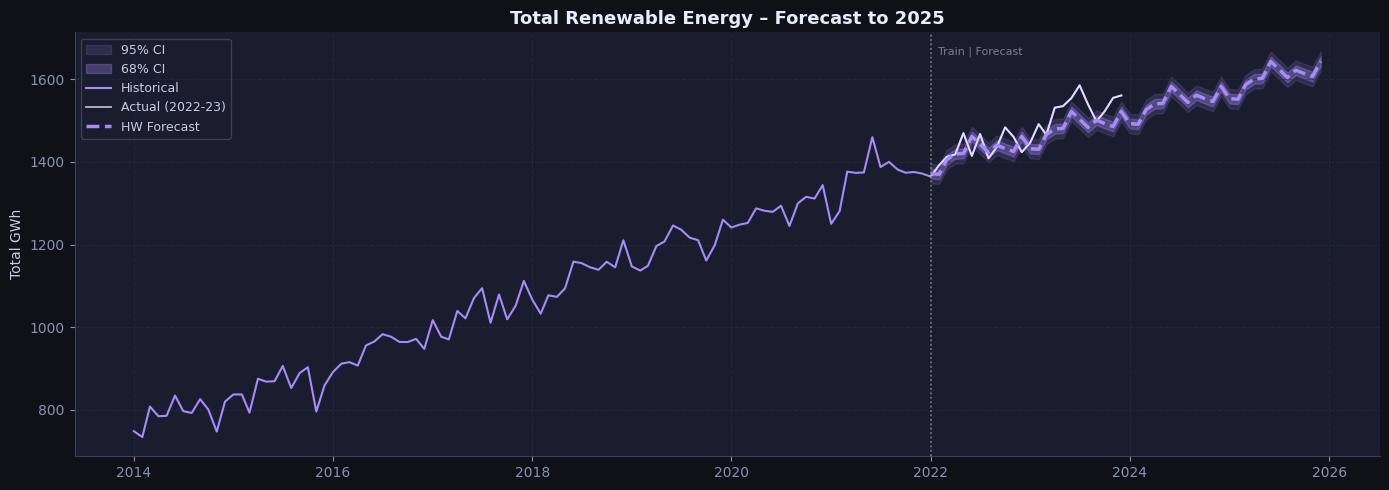

In [14]:
# Combined Total Energy Forecast
# Build best-model forecasts for each source and sum
total_train = df.loc[train_mask, sources].sum(axis=1)
total_test  = df.loc[test_mask,  sources].sum(axis=1)

_, total_hw_fore = holt_winters_forecast(total_train, h=forecast_h)
resid_std_total  = total_train.std() * 0.06

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title('Total Renewable Energy – Forecast to 2025', fontsize=13, fontweight='bold')

ax.fill_between(forecast_dates,
                np.clip(total_hw_fore - 2*resid_std_total, 0, None),
                total_hw_fore + 2*resid_std_total,
                alpha=0.15, color=COLORS['Total'], label='95% CI')
ax.fill_between(forecast_dates,
                np.clip(total_hw_fore - resid_std_total, 0, None),
                total_hw_fore + resid_std_total,
                alpha=0.3, color=COLORS['Total'], label='68% CI')
ax.plot(df.index, df['Total'],      color=COLORS['Total'], lw=1.5, label='Historical')
ax.plot(total_test.index, total_test, color='white', lw=1.3, alpha=0.7, label='Actual (2022-23)')
ax.plot(forecast_dates, total_hw_fore, color=COLORS['Total'], lw=2.5, linestyle='--', label='HW Forecast')
ax.axvline(pd.Timestamp(TEST_START), color='grey', linestyle=':', lw=1.2)
ax.text(pd.Timestamp(TEST_START), ax.get_ylim()[1]*0.98, '  Train | Forecast',
        color='grey', fontsize=8, va='top')
ax.set_ylabel('Total GWh')
ax.legend(fontsize=9, framealpha=0.2)
ax.grid(True)
plt.tight_layout()
plt.show()